In [5]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [6]:
train_dir = r"C:\Users\VAIBHAV\Downloads\archive (2)\training_set\training_set" 
test_dir = r"C:\Users\VAIBHAV\Downloads\archive (2)\test_set\test_set"

In [7]:
train_datagen = ImageDataGenerator( 
    rescale=1./255, 
    shear_range=0.2, 
    zoom_range=0.2, 
    horizontal_flip=True
)
test_datagen = ImageDataGenerator( 
    rescale=1./255 
)

In [8]:
train_generator = train_datagen.flow_from_directory(
    train_dir, 
    target_size=(32,32), 
    batch_size=32, 
    class_mode='binary' 
)

test_generator = test_datagen.flow_from_directory( 
    test_dir, 
    target_size=(32,32), 
    batch_size=32,
    class_mode='binary' )

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [10]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

C:\Users\VAIBHAV\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [68]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

In [21]:
print(train_generator.samples)
print(test_generator.samples)

8005
2023


In [36]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [64]:
img_path = input("Enter image path: ")
img = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)
print("Raw output:", prediction)
if prediction[0][0] > 0.5:
    print("Prediction: Dog 🐶")
else:
    print("Prediction: Cat 🐱")

Enter image path:  C:\Users\VAIBHAV\Downloads\archive (2)\training_set\training_set\cats\cat.98.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Raw output: [[1.]]
Prediction: Dog 🐶


{'cats': 0, 'dogs': 1}


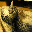

In [65]:
print(train_generator.class_indices)
image.load_img(img_path, target_size=(32,32))
